# Organização do banco de dados e importação de bibliotecas

## Importação de bibliotecas:

In [2]:
import os
import copy
import json
import time
import random
from pathlib import Path
#import yaml
import itertools
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn.conv import GCNConv, ChebConv
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors


import sys
sys.path.append("C:/Users/loren/GNNGCN-proj/src")

from Data.file_utils import create_next_experiment_folder
from Models.models_utils import reset_weights
from Data.prepare_data import create_sliding_windows, train_split, create_batchs
from Data.preprocessing import (normalize_tp, 
                                normalize_features, 
                                assert_finite,
                                fit_log1p_zscore_stats,
                                apply_log1p_zscore)
                                
from Data.feature_extraction import (daily_vertical_velocity, 
                                     get_vv, daily_temp_features, 
                                     get_temp, 
                                     daily_wind_uv_features,
                                     era5_uv_to_tensor,
                                     station_dictionary,
                                     haversine_km,
                                     tensor_data_precip,
                                     era5_specific_humidity_tensor,
                                     forecast_steps_to_daily_precip,
                                     era5_daily_precip_all,
                                     daily_precip_dataset_to_tensor,
                                     get_wind_uv
                                     )    
          
from Evaluation.metrics import safe_r2, safe_mape, combined_loss, weighted_mse_loss

from Evaluation.comparison_plots import save_error_plots, plot_heatmap_nn, model_weights_hist, plot_heatmap_nn, scatter_true_pred
from Graph.graph_related_utils import adjacency_matrix, knn_topology, plot_graph, graph_matrix_index, distance_graph
from Training.Training_Routines import eval_with_loader, train_batched_only


device = "cuda" if torch.cuda.is_available() else "cpu"

RUN_MODE = "full"  # quick or full
if RUN_MODE == "full":
    start_date = "1980-01-01"
    end_date = "2025-12-31"

else:
    start_date = "2024-01-01"
    end_date = "2025-12-31"

In [3]:
def get_var_at_stations(ds: xr.Dataset,
                        var_name: str,
                        t1: str,
                        t2: str,
                        stations: dict) -> np.ndarray:
    """
    Extrai a variável `var_name` de um dataset ERA5 nos pontos das estações.
    Retorna array (T, N) com a série temporal diária para cada estação.
    """
    da = ds[var_name].sel(time=slice(t1, t2))                # Recorta o intervalo temporal desejado
 
    # Detecta os nomes das coordenadas espaciais (ERA5 usa latitude/longitude)
    lat_name = "latitude" if "latitude" in da.dims else "lat"   # Nome do eixo de latitude
    lon_name = "longitude" if "longitude" in da.dims else "lon" # Nome do eixo de longitude
 
    series = []                                              # Lista para acumular séries por estação
    for sid, info in stations.items():                       # Itera sobre cada estação no dicionário
        lat, lon = info["lat"], info["lon"]                  # Coordenadas da estação atual
        s = da.sel({lat_name: lat, lon_name: lon},           # Interpolação por vizinho mais próximo
                   method="nearest").values                  # Converte para NumPy
        series.append(s)                                     # Acumula a série da estação
 
    arr = np.stack(series, axis=1)                           # Empilha → shape (T, N)
 
    # Se a série é horária, agrega para diária (média do dia)
    if len(arr) > (pd.to_datetime(t2) - pd.to_datetime(t1)).days + 1:
        # Recria com índice temporal e faz resample diário
        time_index = pd.to_datetime(da["time"].values)       # Índice de tempo do xarray
        df = pd.DataFrame(arr, index=time_index)             # DataFrame para usar resample
        arr = df.resample("D").mean().values                 # Média diária por estação
 
    return arr.astype(np.float32)                            # Retorna como float32

## Listagem de estações e estação escolhida:

In [4]:
catalog_dir = Path("C:/Users/loren/GNNGCN-proj") / "Datasets" / "dados_inmet"
catalog_file = list(catalog_dir.glob("Catalogo*.csv"))[0]
catalogo_inmet = pd.read_csv(catalog_file, sep=';')
estacoes_RS = station_dictionary(catalogo_inmet)

estacoes = list(estacoes_RS.keys())
print(f"Estação no índice 32: {estacoes[32]}")
print(f"Coordenadas: {estacoes_RS[estacoes[32]]}")

Estação no índice 32: PORTO ALEGRE - JARDIM BOTANICO
Coordenadas: ['-30.05361111', '-51.17472221']


## Carregamento do banco de dados:

In [5]:
base = "C:/Users/loren/GNNGCN-proj"
nc_dir = os.path.join(base, "Datasets", "nc_files")          # Pasta com os arquivos NetCDF
 
start_date = "2024-01-01"                                    # Início do período
end_date   = "2025-12-31"                                    # Fim do período
 
# Carrega os três datasets (precipitação, temperatura, umidade/orvalho)
rea_tp = xr.open_dataset(os.path.join(nc_dir, "era5_precipitation_80-26.nc")).sel(time=slice(start_date, end_date))   # Precipitação
rea_temp  = xr.open_dataset(os.path.join(nc_dir, "temp_05-25.nc")).sel(time=slice(start_date, end_date))     # Temperatura 2m (t2m)
rea_vv = xr.open_dataset(os.path.join(nc_dir, "era5_vv_06-25.nc")).sel(time=slice(start_date, end_date))        # Vertical Velocity
 
T = (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days + 1   # Total de dias
N = len(estacoes_RS)                                                    # Total de estações
 
 

In [6]:
vv_daily_dataset   = daily_vertical_velocity(rea_vv, var_name="w")
temp_daily_dataset = daily_temp_features(rea_temp)
tp_daily_dataset   = forecast_steps_to_daily_precip(rea_tp, to_mm=True).isel(time=slice(None, -1))

In [7]:
X_tp = daily_precip_dataset_to_tensor(tp_daily_dataset, stations=estacoes_RS).reshape(T, N, 1)

X_year = torch.tensor(
    [[np.sin(np.pi * (t % 365 + 1) / 365) for _ in range(N)] for t in range(T)],
    dtype=torch.float32,
).reshape(T, N, 1)

X_t = get_temp(start_date, end_date, temp_daily_dataset, estacoes_RS)
X_vv = get_vv(start_date, end_date, vv_daily_dataset, estacoes_RS)

In [8]:
# Itera sobre os valores e converte string -> float
coords = np.array([[float(lat), float(lon)] for lat, lon in estacoes_RS.values()],
                  dtype=np.float64)
nomes = list(estacoes_RS.keys())   # guarde se quiser saber qual nó é qual estação
N = coords.shape[0]

# Escolha dos k-vizinhos e criação da matriz de adjacências

## Escolha dos k-vizinhos:

In [9]:
k = 2

## Matriz de adjacências via vizinhos:

In [10]:
nbrs = NearestNeighbors(n_neighbors=k+1).fit(coords)
_, idx = nbrs.kneighbors(coords)
idx = idx[:, 1:]

# Cria uma matriz N x N preenchida com zeros
A = np.zeros((N, N), dtype=np.float32)

# Para cada nó i, marca como 1 a posição dos seus k vizinhos mais próximos.
# A[i, idx[i]] = 1.0 indica "existe aresta de i para cada vizinho na lista idx[i]".
# Note: nesse passo, A ainda é direcional (i -> j não implica j -> i).
for i in range(N):
    A[i, idx[i]] = 1.0

# Torna a matriz simétrica via "OU" entre A e sua transposta.
# np.maximum(A, A.T) garante que se i é vizinho de j OU j é vizinho de i, a aresta existe nos dois sentidos.
# Isso transforma o grafo k-NN direcionado em um grafo não-direcionado (vizinhança mútua).
A = np.maximum(A, A.T)

# Adiciona self-loops (cada nó conectado a si mesmo) somando a matriz identidade.
# Self-loops fazem com que, na agregação A @ X, cada nó preserve suas próprias features
# junto com as dos vizinhos, em vez de ser substituído apenas pela média da vizinhança.
A = A + np.eye(N, dtype=np.float32)

# Agregação por média

# Calcula o grau de cada nó (soma das conexões na linha) — quantos vizinhos cada um tem (incluindo self-loop).
# keepdims=True mantém shape (N, 1) para permitir broadcasting na divisão linha a linha.
deg = A.sum(axis=1, keepdims=True)

# Divide cada linha de A pelo grau correspondente, transformando soma em média.
# Resultado: cada linha de A_norm soma 1 — agregação vira "média das features dos vizinhos".
A_norm = torch.tensor(A / deg, dtype=torch.float32) 

## Matriz:

In [11]:
print(A_norm)

tensor([[0.3333, 0.0000, 0.3333,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.1667, 0.0000,  ..., 0.0000, 0.1667, 0.0000],
        [0.2000, 0.0000, 0.2000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.3333, 0.0000, 0.0000],
        [0.0000, 0.3333, 0.0000,  ..., 0.0000, 0.3333, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.3333]])


# Modelo

## Escolha da data-alvo:

In [12]:
target_date = "2024-05-04" # Data-alvo

# "2024-05-04": Dia com muita chuva;
# "2025-01-12": Dia com pouca chuva;
# "2025-02-08": Dia com zero chuva;

## Estrutura do modelo:

In [13]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

n_idx = 32 # ID da estação (32 - Porto Alegre, Jardim Botânico)
F_in  = 2 # F_in é a dimensão das features de entrada. Como estamos tratando 
          # de umidade e velocidade vertical, a dimensão é 2.
epochs = 200 # Épocas
hidden = 2 # Número de neurônios na camada oculta
lr = 1e-3 # Taxa de aprendizado "eta".

# Proporções do split (por nós)
p_train = 0.70
p_val   = 0.10
p_test  = 0.20  # implícito: 1 - p_train - p_val

# =====================================================
# 2) Monta entrada e target para o dia alvo
# =====================================================
t_idx = (pd.to_datetime(target_date) - pd.to_datetime(start_date)).days

vv_t = X_vv[t_idx, :, 0]
t_t  = X_t [t_idx, :, 0]
X_in = torch.stack([vv_t, t_t], dim=-1).float()   # (N, 2)

y_all = X_tp[t_idx, :, 0].float()                 # (N,)

N = X_in.shape[0]   # nº total de nós

# =====================================================
# 2.1) Split por nós: treino / validação / teste
# =====================================================
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(N, generator=g)

n_train = int(round(p_train * N))
n_val   = int(round(p_val   * N))
n_test  = N - n_train - n_val

idx_train = perm[:n_train]
idx_val   = perm[n_train : n_train + n_val]
idx_test  = perm[n_train + n_val:]

def make_mask(indices, N):
    m = torch.zeros(N, dtype=torch.bool)
    m[indices] = True
    return m

mask_train = make_mask(idx_train, N)
mask_val   = make_mask(idx_val,   N)
mask_test  = make_mask(idx_test,  N)

print(f"Total de nós: {N}")
print(f"  Treino: {mask_train.sum().item()}  "
      f"Val: {mask_val.sum().item()}  "
      f"Teste: {mask_test.sum().item()}")

Total de nós: 62
  Treino: 43  Val: 6  Teste: 13


## Modelo de GNN com quantidade variável de camadas ocultas:

In [14]:
n_hidden_layers = 6  # escolha aqui: 1, 2, 3, 6, 10, ...

In [15]:
# Modelo: GNN simples com quantidade variavel de camadas ocultas

class SimpleGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim, n_hidden_layers=6, out_dim=1):
        super().__init__()

        self.hidden_layers = nn.ModuleList()

        # Primeira camada oculta: entrada -> hidden
        self.hidden_layers.append(
            nn.Linear(in_dim, hidden_dim)
        )

        # Demais camadas ocultas: hidden -> hidden
        for _ in range(n_hidden_layers - 1):
            self.hidden_layers.append(
                nn.Linear(hidden_dim, hidden_dim)
            )

        self.W_out = nn.Linear(hidden_dim, out_dim)

    def forward(self, X, A_norm):
        H = X

        for layer in self.hidden_layers:
            H = A_norm @ H
            H = F.relu(layer(H))

        out = self.W_out(H)
        return out.squeeze(-1)


modelo = SimpleGNN(
    in_dim=F_in,
    hidden_dim=hidden,
    n_hidden_layers=n_hidden_layers
)

otimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
loss_fn = nn.MSELoss()

In [16]:
import copy
import itertools
import pandas as pd
import matplotlib.pyplot as plt

def run_experiment(epochs, hidden, X_in, y_all, A_norm,
                   mask_train, mask_val, mask_test,
                   F_in=2, lr=1e-3, n_idx=32, seed=42,
                   patience=20, min_delta=1e-5):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    modelo = SimpleGNN(in_dim=F_in, hidden_dim=hidden)
    otimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    loss_fn = nn.MSELoss()


    historico = {
        "train_loss": [],
        "val_loss": [],
        "test_loss": [],
    }

    best_val = float("inf")
    best_epoch = 0
    stop_epoch = epochs
    patience_count = 0
    best_state = copy.deepcopy(modelo.state_dict())

    for epoca in range(epochs + 1):
        modelo.train()
        otimizador.zero_grad()

        y_pred_all = modelo(X_in, A_norm)
        loss_train = loss_fn(y_pred_all[mask_train], y_all[mask_train])

        loss_train.backward()
        otimizador.step()

        modelo.eval()
        with torch.no_grad():
            y_pred_eval = modelo(X_in, A_norm)
            loss_val = loss_fn(y_pred_eval[mask_val], y_all[mask_val])
            loss_test = loss_fn(y_pred_eval[mask_test], y_all[mask_test])

        historico["train_loss"].append(loss_train.item())
        historico["val_loss"].append(loss_val.item())
        historico["test_loss"].append(loss_test.item())

        if loss_val.item() < best_val - min_delta:
            best_val = loss_val.item()
            best_epoch = epoca
            best_state = copy.deepcopy(modelo.state_dict())
            patience_count = 0
        else:
            patience_count += 1

        if patience_count >= patience:
            stop_epoch = epoca
            break

    modelo.load_state_dict(best_state)

    modelo.eval()
    with torch.no_grad():
        y_pred_all = modelo(X_in, A_norm)

        loss_train_f = loss_fn(y_pred_all[mask_train], y_all[mask_train]).item()
        loss_val_f   = loss_fn(y_pred_all[mask_val],   y_all[mask_val]).item()
        loss_test_f  = loss_fn(y_pred_all[mask_test],  y_all[mask_test]).item()
        pred_no      = y_pred_all[n_idx].item()
        true_no      = y_all[n_idx].item()

    return {
        "epochs":      epochs,
        "hidden":      hidden,
        "best_epoch":  best_epoch,
        "stop_epoch":  stop_epoch,
        "loss_train":  loss_train_f,
        "loss_val":    loss_val_f,
        "loss_test":   loss_test_f,
        "pred":        pred_no,
        "true":        true_no,
        "historico":   historico,
    }


In [17]:
epochs_grid = [100, 200, 400, 500, 1000]
hidden_grid = [2, 6, 12, 24]

resultados = []
historicos = {}
paradas = {}

for ep, hd in itertools.product(epochs_grid, hidden_grid):
    print(f"Rodando epochs={ep}, hidden={hd}...")

    r = run_experiment(
        ep,
        hd,
        X_in,
        y_all,
        A_norm,
        mask_train,
        mask_val,
        mask_test,
        patience=60,
        min_delta=1e-4
    )

    historicos[(ep, hd)] = r["historico"]
    paradas[(ep, hd)] = r["stop_epoch"]

    r_sem_historico = r.copy()
    del r_sem_historico["historico"]
    resultados.append(r_sem_historico)

df = pd.DataFrame(resultados)
print(df)

from pathlib import Path

# Pasta onde o arquivo sera salvo
output_dir = Path("../Results")
output_dir.mkdir(parents=True, exist_ok=True)

# Deixa a data em formato adequado para nome de arquivo
target_date_file = target_date.replace("-", "")

# Nome do arquivo usando os parametros do modelo
nome_arquivo = f"GNNResults-K{k}-HL{n_hidden_layers}-D{target_date_file}.csv"

# Caminho completo do arquivo
output_path = output_dir / nome_arquivo

# Salva o dataframe
df.to_csv(output_path, index=False)

print(f"Arquivo salvo em: {output_path}")

Rodando epochs=100, hidden=2...
Rodando epochs=100, hidden=6...
Rodando epochs=100, hidden=12...
Rodando epochs=100, hidden=24...
Rodando epochs=200, hidden=2...
Rodando epochs=200, hidden=6...
Rodando epochs=200, hidden=12...
Rodando epochs=200, hidden=24...
Rodando epochs=400, hidden=2...
Rodando epochs=400, hidden=6...
Rodando epochs=400, hidden=12...
Rodando epochs=400, hidden=24...
Rodando epochs=500, hidden=2...
Rodando epochs=500, hidden=6...
Rodando epochs=500, hidden=12...
Rodando epochs=500, hidden=24...
Rodando epochs=1000, hidden=2...
Rodando epochs=1000, hidden=6...
Rodando epochs=1000, hidden=12...
Rodando epochs=1000, hidden=24...
    epochs  hidden  best_epoch  stop_epoch   loss_train     loss_val  \
0      100       2         100         100  1549.316650  1183.188354   
1      100       6         100         100  1532.366699  1165.897827   
2      100      12         100         100  1212.277100   833.786621   
3      100      24          88         100   630.436646   

Grafico salvo em: ..\Graphics\GNNGraphics-K2-HL6-D20240504.png


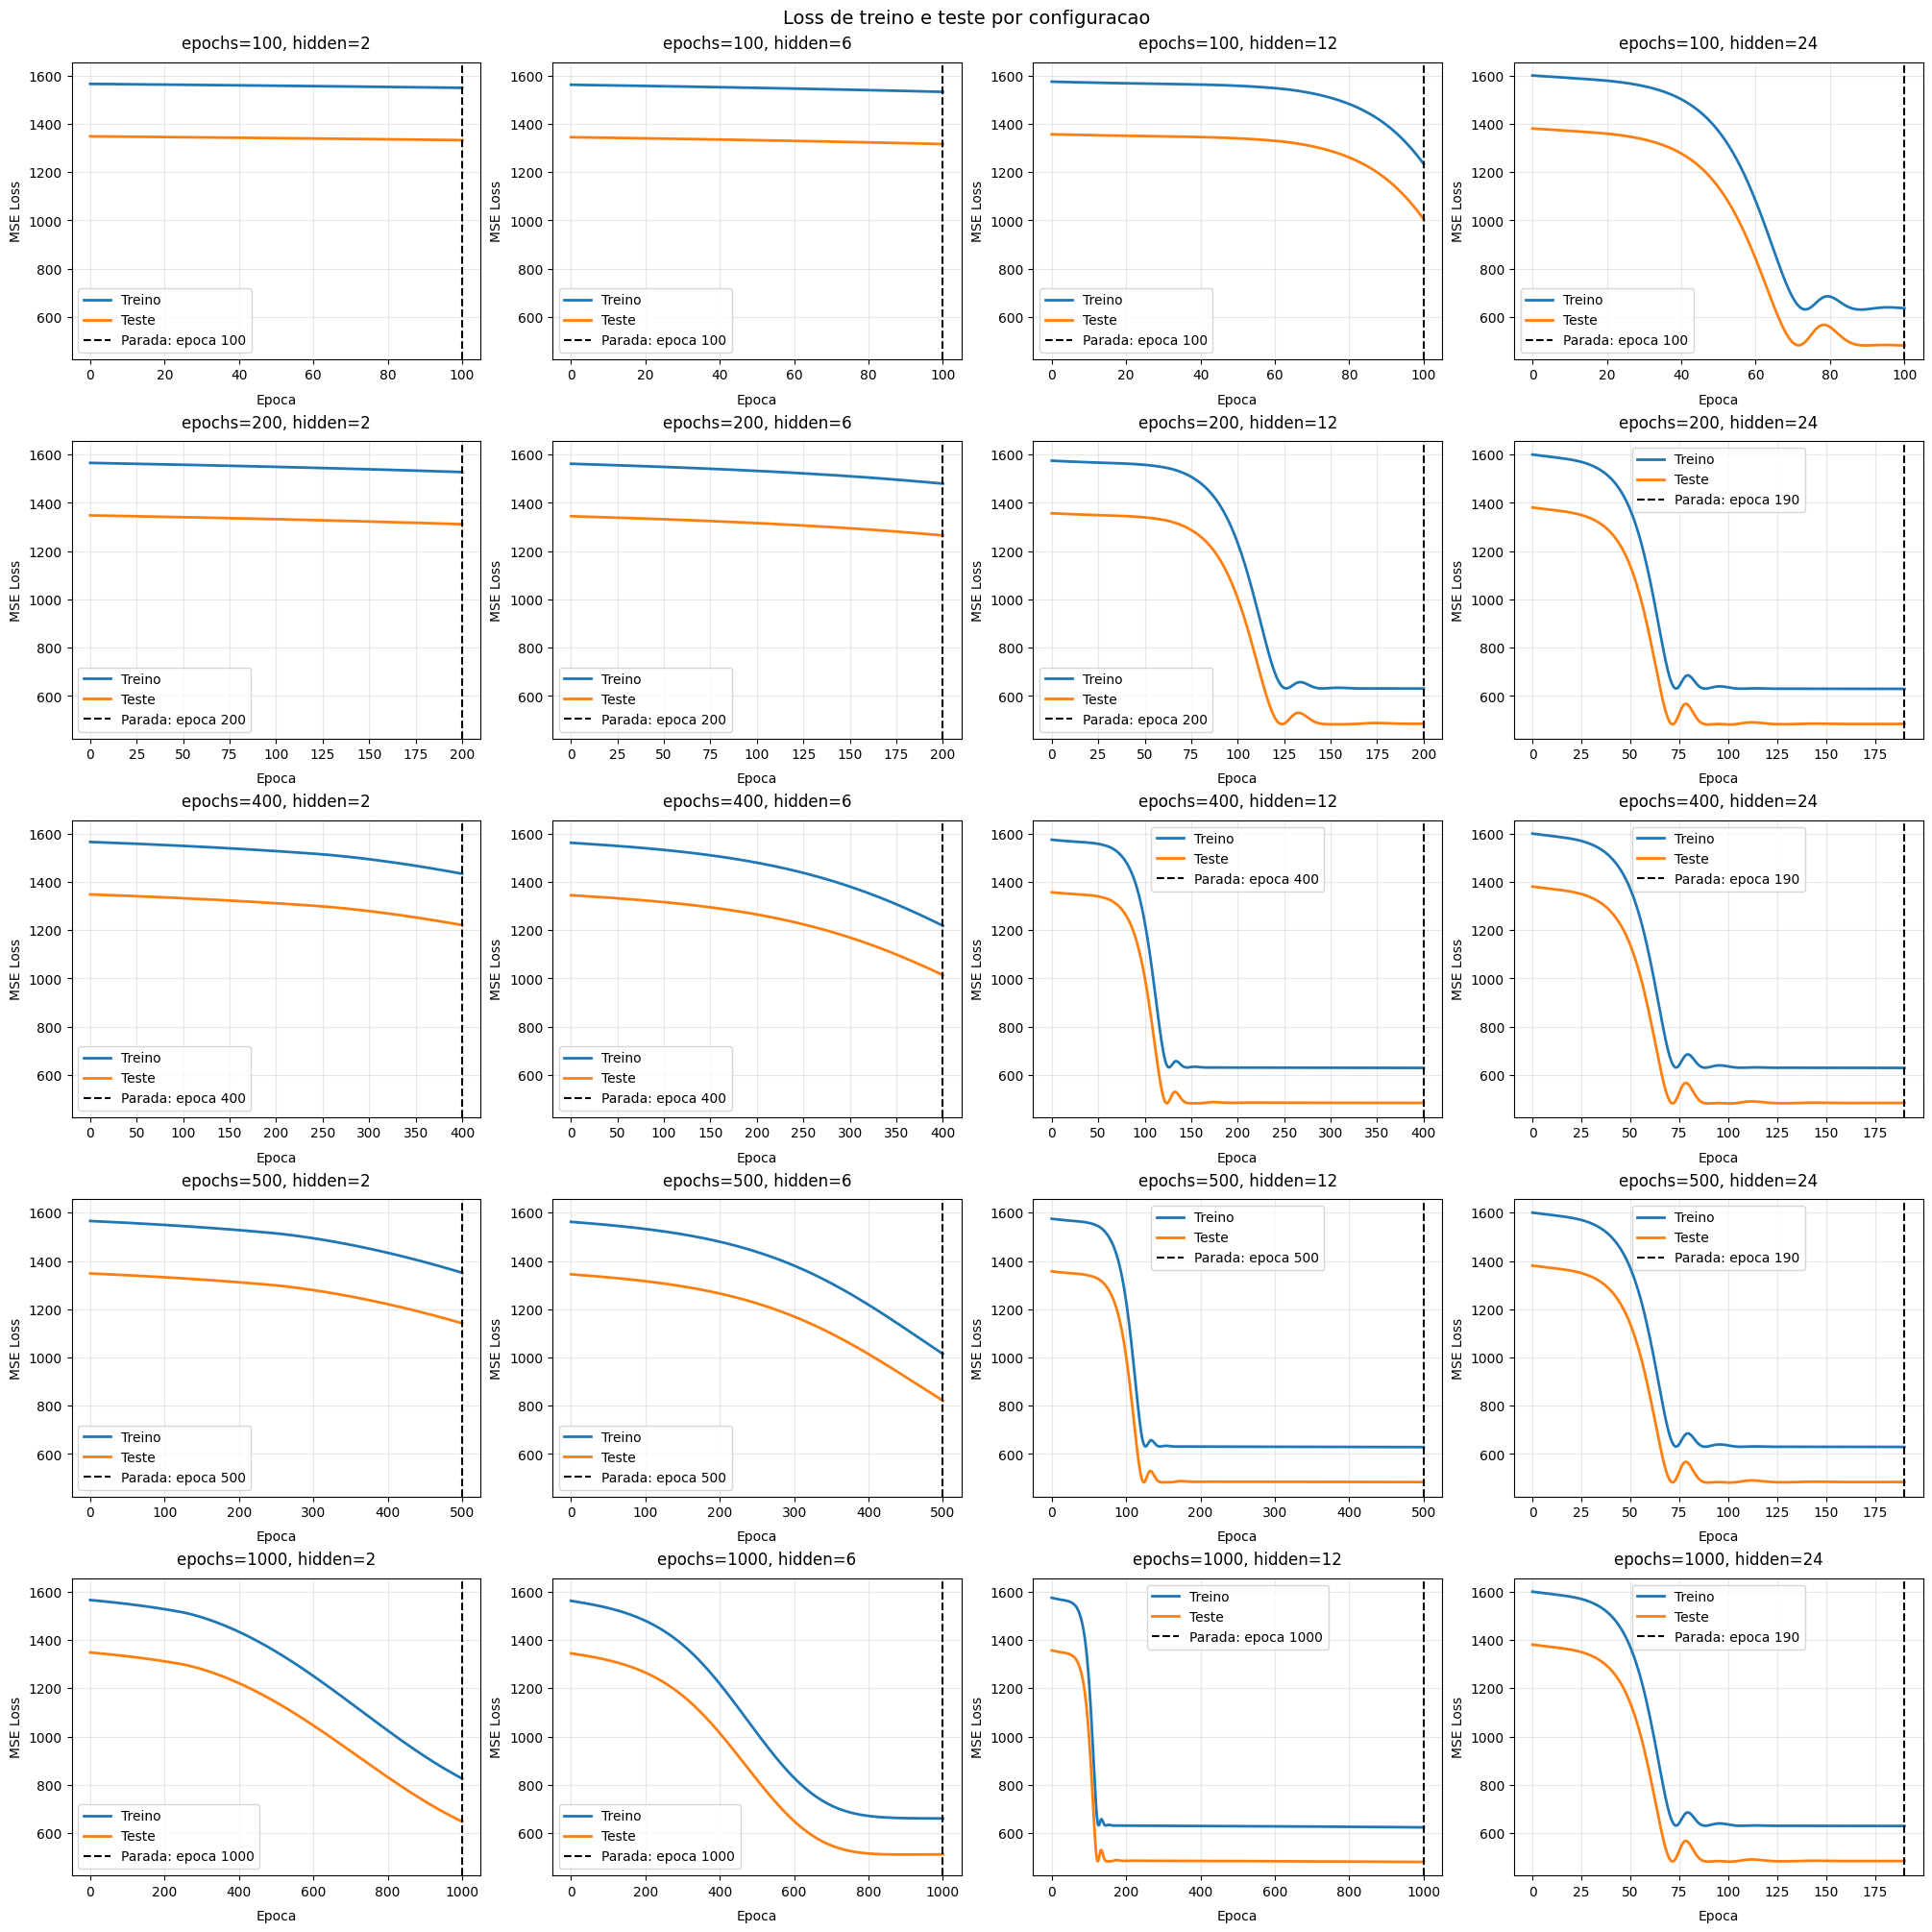

In [18]:
from pathlib import Path

# =====================================================
# Graficos: loss de treino e teste
# =====================================================

n_linhas = len(epochs_grid)
n_colunas = len(hidden_grid)

todos_losses = []

for ep in epochs_grid:
    for hd in hidden_grid:
        hist = historicos[(ep, hd)]
        todos_losses.extend(hist["train_loss"])
        todos_losses.extend(hist["test_loss"])

y_min = min(todos_losses)
y_max = max(todos_losses)

margem = 0.05 * (y_max - y_min)

if margem == 0:
    margem = 1

y_min -= margem
y_max += margem

fig, axes = plt.subplots(
    n_linhas,
    n_colunas,
    figsize=(5 * n_colunas, 4 * n_linhas),
    sharey=True,
    constrained_layout=True
)

axes = np.array(axes).reshape(n_linhas, n_colunas)

for i, ep in enumerate(epochs_grid):
    for j, hd in enumerate(hidden_grid):
        ax = axes[i, j]

        hist = historicos[(ep, hd)]
        epocas = range(len(hist["train_loss"]))

        ax.plot(
            epocas,
            hist["train_loss"],
            label="Treino",
            color="tab:blue",
            linewidth=2
        )

        ax.plot(
            epocas,
            hist["test_loss"],
            label="Teste",
            color="tab:orange",
            linewidth=2
        )

        stop_epoch = paradas[(ep, hd)]

        ax.axvline(
            stop_epoch,
            color="black",
            linestyle="--",
            linewidth=1.5,
            label=f"Parada: epoca {stop_epoch}"
        )

        ax.set_title(f"epochs={ep}, hidden={hd}", pad=10)
        ax.set_xlabel("Epoca", labelpad=8)
        ax.set_ylabel("MSE Loss")
        ax.set_ylim(y_min, y_max)

        ax.tick_params(axis="y", labelleft=True)

        ax.grid(alpha=0.3)
        ax.legend(loc="best")

fig.suptitle("Loss de treino e teste por configuracao", fontsize=14)

# =====================================================
# Salvar imagem
# =====================================================

graphics_dir = Path("../Graphics")
graphics_dir.mkdir(parents=True, exist_ok=True)

target_date_file = target_date.replace("-", "")

nome_imagem = f"GNNGraphics-K{k}-HL{n_hidden_layers}-D{target_date_file}.png"
output_path = graphics_dir / nome_imagem

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Grafico salvo em: {output_path}")

plt.show()

Passagem de dataframe para LaTeX (tabelas do Overleaf)

In [20]:
caption = (
    f"Resultados experimentais da GNN em {target_date}, "
    f"com k={k}, hidden={n_hidden_layers}, epochs={epochs} e lr={lr}."
)

latex = df.to_latex(
    index=False,
    escape=True,
    float_format=lambda x: f"{x:.6f}",
    caption=caption,
    label=f"tab:gnn_results_k{k}_hidden{n_hidden_layers}",
    column_format="c" * len(df.columns),
    position="h",
)

latex = latex.replace(
    "\\begin{table}[h]",
    "\\begin{table}[h]\n\\centering"
)

out_dir = Path("../Tables")
out_dir.mkdir(parents=True, exist_ok=True)

out_file = out_dir / f"GNNTable_K{k}_HL{n_hidden_layers}_D{target_date_file}.tex"

out_file.write_text(latex, encoding="utf-8")

print(f"Tabela GNN salva em: {out_file}")

Tabela GNN salva em: ..\Tables\GNNTable_K2_HL6_D20240504.tex


## Losses dos outros nós do banco de teste, GNN (adaptar)

In [23]:
from pathlib import Path

modelo.eval()
with torch.no_grad():
    y_pred_all = modelo(X_in, A_norm)

    erro_sq = (y_pred_all - y_all) ** 2
    erro_abs = (y_pred_all - y_all).abs()

idx_teste = torch.where(mask_test)[0]

df_teste = pd.DataFrame({
    "no": idx_teste.cpu().numpy(),
    "estacao": [estacoes[i] for i in idx_teste.cpu().numpy()],
    "y_real": y_all[mask_test].cpu().numpy(),
    "y_pred": y_pred_all[mask_test].cpu().numpy(),
    "erro": (y_pred_all[mask_test] - y_all[mask_test]).cpu().numpy(),
    "erro_abs": erro_abs[mask_test].cpu().numpy(),
    "loss_no": erro_sq[mask_test].cpu().numpy(),
})

df_teste = df_teste.sort_values(
    "loss_no",
    ascending=False
).reset_index(drop=True)

caption_loss = (
    f"Loss por nó de teste da GNN em {target_date}, "
    f"com k={k}, hidden={n_hidden_layers}, epochs={epochs} e lr={lr}."
)

latex_loss = df_teste.to_latex(
    index=False,
    escape=True,
    float_format=lambda x: f"{x:.6f}",
    caption=caption_loss,
    label=f"tab:gnn_loss_nodes_k{k}_hidden{n_hidden_layers}",
    column_format="c" * len(df_teste.columns),
    position="h",
)

latex_loss = latex_loss.replace(
    "\\begin{table}[h]",
    "\\begin{table}[h]\n\\centering"
)

out_dir = Path("../Tables_Loss")
out_dir.mkdir(parents=True, exist_ok=True)

out_file = out_dir / f"GNNLossTable_K{k}_HL{n_hidden_layers}_D{target_date_file}.tex"

out_file.write_text(latex_loss, encoding="utf-8")

print(f"Tabela de losses da GNN salva em: {out_file}")
print(f"Média das losses individuais: {df_teste['loss_no'].mean():.4f}")
print(f"Loss de teste agregada:       {erro_sq[mask_test].mean().item():.4f}")

Tabela de losses da GNN salva em: ..\Tables_Loss\GNNLossTable_K2_HL6_D20240504.tex
Média das losses individuais: 1348.4666
Loss de teste agregada:       1348.4667


## Modelo de GCN com quantidade variável de camadas ocultas:

In [24]:
def normalize_adjacency_gcn(A):
    """
    Normalização usada em GCN:
    
        A_gcn = D^(-1/2) A D^(-1/2)

    Aqui A deve conter as conexões do grafo.
    A diagonal é preenchida com 1 para garantir self-loops.
    """
    if isinstance(A, np.ndarray):
        A = torch.tensor(A, dtype=torch.float32)
    else:
        A = A.clone().detach().float()

    # Transforma em matriz binária de conexão
    A = (A > 0).float()

    # Garante self-loops
    A.fill_diagonal_(1.0)

    # Grau de cada nó
    degree = A.sum(dim=1)

    # D^(-1/2)
    degree_inv_sqrt = torch.pow(degree, -0.5)

    # Evita infinito caso algum nó tenha grau zero
    degree_inv_sqrt[torch.isinf(degree_inv_sqrt)] = 0.0

    # Matriz diagonal D^(-1/2)
    D_inv_sqrt = torch.diag(degree_inv_sqrt)

    # Normalização simétrica da GCN
    A_gcn = D_inv_sqrt @ A @ D_inv_sqrt

    return A_gcn

A_gcn = normalize_adjacency_gcn(A)

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, X, A_gcn):
        H = A_gcn @ X
        H = self.linear(H)
        return H


class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, n_hidden_layers=6, out_dim=1, dropout=0.0):
        super().__init__()

        self.hidden_layers = nn.ModuleList()
        self.dropout = dropout

        # Primeira camada oculta: entrada -> hidden
        self.hidden_layers.append(
            GCNLayer(in_dim, hidden_dim)
        )

        # Demais camadas ocultas: hidden -> hidden
        for _ in range(n_hidden_layers - 1):
            self.hidden_layers.append(
                GCNLayer(hidden_dim, hidden_dim)
            )

        # Camada de saida: hidden -> out
        self.output_layer = GCNLayer(hidden_dim, out_dim)

    def forward(self, X, A_gcn):
        H = X

        for layer in self.hidden_layers:
            H = layer(H, A_gcn)
            H = F.relu(H)
            H = F.dropout(H, p=self.dropout, training=self.training)

        out = self.output_layer(H, A_gcn)

        return out.squeeze(-1)


modelo = GCN(
    in_dim=F_in,
    hidden_dim=hidden,
    n_hidden_layers=n_hidden_layers,
    out_dim=1,
    dropout=0.0
)

otimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
loss_fn = nn.MSELoss()

In [25]:
import copy
import itertools
import pandas as pd
import matplotlib.pyplot as plt

def run_experiment_gcn(
    epochs,
    hidden,
    n_hidden_layers,
    X_in,
    y_all,
    A_gcn,
    mask_train,
    mask_val,
    mask_test,
    F_in=2,
    lr=1e-3,
    n_idx=32,
    seed=42,
    patience=20,
    min_delta=1e-5,
    dropout=0.0,
):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.cuda.manual_seed_all(seed)

    modelo = GCN(
        in_dim=F_in,
        hidden_dim=hidden,
        n_hidden_layers=n_hidden_layers,
        out_dim=1,
        dropout=dropout
    )

    otimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    historico = {
        "train_loss": [],
        "val_loss": [],
        "test_loss": [],
    }

    best_val = float("inf")
    best_epoch = 0
    stop_epoch = epochs
    patience_count = 0
    best_state = copy.deepcopy(modelo.state_dict())

    for epoca in range(epochs + 1):
        modelo.train()
        otimizador.zero_grad()

        y_pred_all = modelo(X_in, A_gcn)
        loss_train = loss_fn(y_pred_all[mask_train], y_all[mask_train])

        loss_train.backward()
        otimizador.step()

        modelo.eval()
        with torch.no_grad():
            y_pred_eval = modelo(X_in, A_gcn)

            loss_val = loss_fn(y_pred_eval[mask_val], y_all[mask_val])
            loss_test = loss_fn(y_pred_eval[mask_test], y_all[mask_test])

        historico["train_loss"].append(loss_train.item())
        historico["val_loss"].append(loss_val.item())
        historico["test_loss"].append(loss_test.item())

        if loss_val.item() < best_val - min_delta:
            best_val = loss_val.item()
            best_epoch = epoca
            best_state = copy.deepcopy(modelo.state_dict())
            patience_count = 0
        else:
            patience_count += 1

        if patience_count >= patience:
            stop_epoch = epoca
            break

    modelo.load_state_dict(best_state)

    modelo.eval()
    with torch.no_grad():
        y_pred_all = modelo(X_in, A_gcn)

        loss_train_f = loss_fn(y_pred_all[mask_train], y_all[mask_train]).item()
        loss_val_f   = loss_fn(y_pred_all[mask_val],   y_all[mask_val]).item()
        loss_test_f  = loss_fn(y_pred_all[mask_test],  y_all[mask_test]).item()

        mae = lambda a, b: (a - b).abs().mean().item()

        mae_train = mae(y_pred_all[mask_train], y_all[mask_train])
        mae_val   = mae(y_pred_all[mask_val],   y_all[mask_val])
        mae_test  = mae(y_pred_all[mask_test],  y_all[mask_test])

        pred_no = y_pred_all[n_idx].item()
        true_no = y_all[n_idx].item()

    return {
        "epochs": epochs,
        "hidden": hidden,
        "n_hidden_layers": n_hidden_layers,
        "best_epoch": best_epoch,
        "stop_epoch": stop_epoch,
        "loss_train": loss_train_f,
        "loss_val": loss_val_f,
        "loss_test": loss_test_f,
        "mae_train": mae_train,
        "mae_val": mae_val,
        "mae_test": mae_test,
        "pred": pred_no,
        "true": true_no,
        "historico": historico,
    }

In [26]:
resultados = []
historicos = {}
paradas = {}

for ep, hd in itertools.product(epochs_grid, hidden_grid):
    print(f"Rodando GCN epochs={ep}, hidden={hd}...")

    r = run_experiment_gcn(
        epochs=ep,
        hidden=hd,
        n_hidden_layers=n_hidden_layers,
        X_in=X_in,
        y_all=y_all,
        A_gcn=A_gcn,
        mask_train=mask_train,
        mask_val=mask_val,
        mask_test=mask_test,
        F_in=F_in,
        lr=lr,
        n_idx=n_idx,
        seed=SEED,
        patience=60,
        min_delta=1e-4,
        dropout=0.0,
    )

    historicos[(ep, hd)] = r["historico"]
    paradas[(ep, hd)] = r["stop_epoch"]

    r_sem_historico = r.copy()
    del r_sem_historico["historico"]

    resultados.append(r_sem_historico)

df_gcn = pd.DataFrame(resultados)
print(df_gcn)


from pathlib import Path

# Pasta onde o arquivo sera salvo
output_dir = Path("../Results")
output_dir.mkdir(parents=True, exist_ok=True)

# Deixa a data em formato adequado para nome de arquivo
target_date_file = target_date.replace("-", "")

# Nome do arquivo usando os parametros do modelo
nome_arquivo = f"GCNResults-K{k}-HL{n_hidden_layers}-D{target_date_file}.csv"

# Caminho completo do arquivo
output_path = output_dir / nome_arquivo

# Salva o dataframe
df_gcn.to_csv(output_path, index=False)

print(f"Arquivo salvo em: {output_path}")

Rodando GCN epochs=100, hidden=2...
Rodando GCN epochs=100, hidden=6...
Rodando GCN epochs=100, hidden=12...
Rodando GCN epochs=100, hidden=24...
Rodando GCN epochs=200, hidden=2...
Rodando GCN epochs=200, hidden=6...
Rodando GCN epochs=200, hidden=12...
Rodando GCN epochs=200, hidden=24...
Rodando GCN epochs=400, hidden=2...
Rodando GCN epochs=400, hidden=6...
Rodando GCN epochs=400, hidden=12...
Rodando GCN epochs=400, hidden=24...
Rodando GCN epochs=500, hidden=2...
Rodando GCN epochs=500, hidden=6...
Rodando GCN epochs=500, hidden=12...
Rodando GCN epochs=500, hidden=24...
Rodando GCN epochs=1000, hidden=2...
Rodando GCN epochs=1000, hidden=6...
Rodando GCN epochs=1000, hidden=12...
Rodando GCN epochs=1000, hidden=24...
    epochs  hidden  n_hidden_layers  best_epoch  stop_epoch   loss_train  \
0      100       2                6         100         100  1549.401123   
1      100       6                6         100         100  1532.405151   
2      100      12                6   

Grafico salvo em: ..\Graphics\GCNGraphics-K2-HL6-D20240504.png


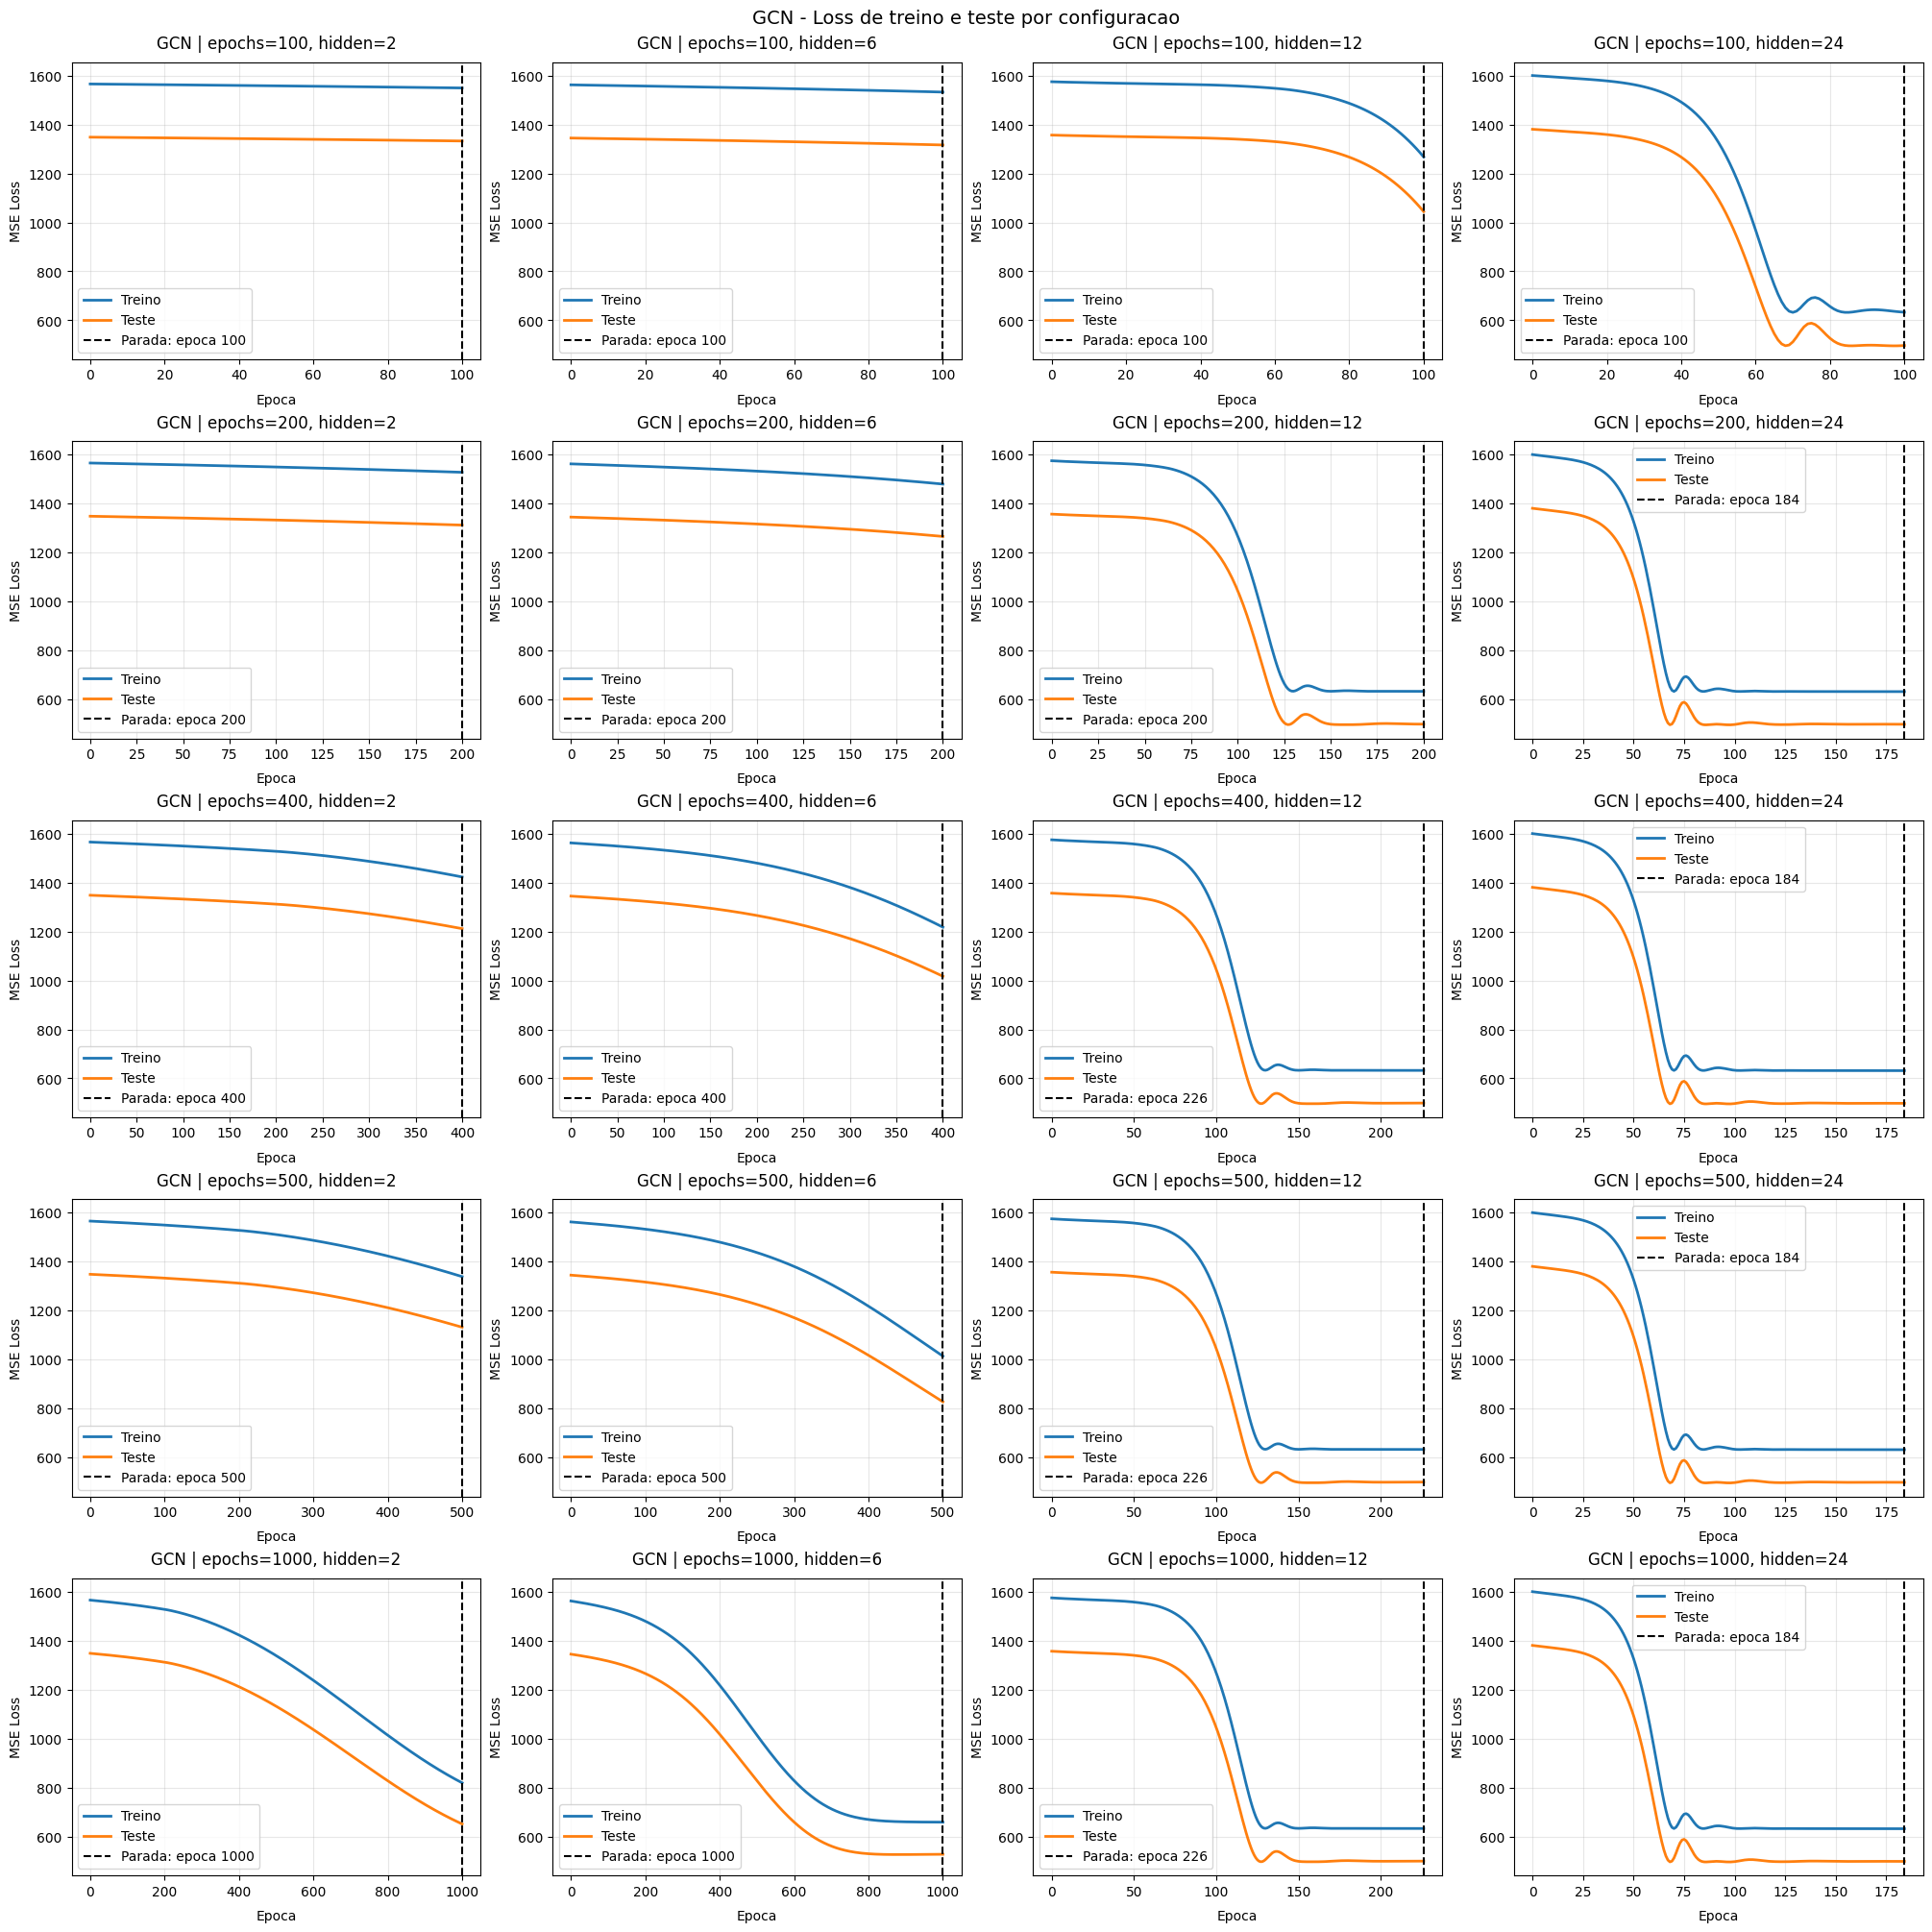

In [27]:
from pathlib import Path

# =====================================================
# Graficos GCN: loss de treino e teste
# =====================================================

n_linhas = len(epochs_grid)
n_colunas = len(hidden_grid)

todos_losses = []

for ep in epochs_grid:
    for hd in hidden_grid:
        hist = historicos[(ep, hd)]
        todos_losses.extend(hist["train_loss"])
        todos_losses.extend(hist["test_loss"])

y_min = min(todos_losses)
y_max = max(todos_losses)

margem = 0.05 * (y_max - y_min)

if margem == 0:
    margem = 1

y_min -= margem
y_max += margem

fig, axes = plt.subplots(
    n_linhas,
    n_colunas,
    figsize=(5 * n_colunas, 4 * n_linhas),
    sharey=True,
    constrained_layout=True
)

axes = np.array(axes).reshape(n_linhas, n_colunas)

for i, ep in enumerate(epochs_grid):
    for j, hd in enumerate(hidden_grid):
        ax = axes[i, j]

        hist = historicos[(ep, hd)]
        epocas = range(len(hist["train_loss"]))

        ax.plot(
            epocas,
            hist["train_loss"],
            label="Treino",
            color="tab:blue",
            linewidth=2
        )

        ax.plot(
            epocas,
            hist["test_loss"],
            label="Teste",
            color="tab:orange",
            linewidth=2
        )

        stop_epoch = paradas[(ep, hd)]

        ax.axvline(
            stop_epoch,
            color="black",
            linestyle="--",
            linewidth=1.5,
            label=f"Parada: epoca {stop_epoch}"
        )

        ax.set_title(f"GCN | epochs={ep}, hidden={hd}", pad=10)
        ax.set_xlabel("Epoca", labelpad=8)
        ax.set_ylabel("MSE Loss")
        ax.set_ylim(y_min, y_max)

        ax.tick_params(axis="y", labelleft=True)

        ax.grid(alpha=0.3)
        ax.legend(loc="best")

fig.suptitle("GCN - Loss de treino e teste por configuracao", fontsize=14)

# =====================================================
# Salvar imagem
# =====================================================

graphics_dir = Path("../Graphics")
graphics_dir.mkdir(parents=True, exist_ok=True)

target_date_file = target_date.replace("-", "")

nome_imagem = f"GCNGraphics-K{k}-HL{n_hidden_layers}-D{target_date_file}.png"
output_path = graphics_dir / nome_imagem

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Grafico salvo em: {output_path}")

plt.show()

In [30]:
cols_gnn = [
    "epochs",
    "hidden",
    "best_epoch",
    "stop_epoch",
    "loss_train",
    "loss_val",
    "loss_test",
    "pred",
    "true",
]

df_gcn_tabela = df_gcn[cols_gnn].copy()

caption_gcn = (
    f"Resultados experimentais da GCN em {target_date}, "
    f"com k={k}, hidden={n_hidden_layers}, epochs={epochs} e lr={lr}."
)

latex_gcn = df_gcn_tabela.to_latex(
    index=False,
    escape=True,
    float_format=lambda x: f"{x:.6f}",
    caption=caption_gcn,
    label=f"tab:gcn_results_k{k}_hidden{n_hidden_layers}",
    column_format="c" * len(df_gcn_tabela.columns),
    position="h",
)

latex_gcn = latex_gcn.replace(
    "\\begin{table}[h]",
    "\\begin{table}[h]\n\\centering"
)

out_dir = Path("../Tables")
out_dir.mkdir(parents=True, exist_ok=True)

out_file = out_dir / f"GCNTable_K{k}_HL{n_hidden_layers}_D{target_date_file}.tex"

out_file.write_text(latex_gcn, encoding="utf-8")

print(f"Tabela GCN salva em: {out_file}")

Tabela GCN salva em: ..\Tables\GCNTable_K2_HL6_D20240504.tex


## Losses dos outros nós do banco de teste, GCN (adaptar)

In [33]:
from pathlib import Path

modelo.eval()
with torch.no_grad():
    y_pred_all = modelo(X_in, A_gcn)

    erro_sq = (y_pred_all - y_all) ** 2
    erro_abs = (y_pred_all - y_all).abs()

idx_teste = torch.where(mask_test)[0]

df_teste_gcn = pd.DataFrame({
    "no": idx_teste.cpu().numpy(),
    "estacao": [estacoes[i] for i in idx_teste.cpu().numpy()],
    "y_real": y_all[mask_test].cpu().numpy(),
    "y_pred": y_pred_all[mask_test].cpu().numpy(),
    "erro": (y_pred_all[mask_test] - y_all[mask_test]).cpu().numpy(),
    "erro_abs": erro_abs[mask_test].cpu().numpy(),
    "loss_no": erro_sq[mask_test].cpu().numpy(),
})

df_teste_gcn = df_teste_gcn.sort_values(
    "loss_no",
    ascending=False
).reset_index(drop=True)

caption_loss_gcn = (
    f"Loss por nó de teste da GCN em {target_date}, "
    f"com k={k}, hidden={n_hidden_layers}, epochs={epochs} e lr={lr}."
)

latex_loss_gcn = df_teste_gcn.to_latex(
    index=False,
    escape=True,
    float_format=lambda x: f"{x:.6f}",
    caption=caption_loss_gcn,
    label=f"tab:gcn_loss_nodes_k{k}_hidden{n_hidden_layers}",
    column_format="c" * len(df_teste_gcn.columns),
    position="h",
)

latex_loss_gcn = latex_loss_gcn.replace(
    "\\begin{table}[h]",
    "\\begin{table}[h]\n\\centering"
)

out_dir = Path("../Tables_Loss")
out_dir.mkdir(parents=True, exist_ok=True)

out_file = out_dir / f"GCNLossTable_K{k}_HL{n_hidden_layers}_D{target_date_file}.tex"

out_file.write_text(latex_loss_gcn, encoding="utf-8")

print(f"Tabela de losses da GCN salva em: {out_file}")
print(f"Média das losses individuais: {df_teste_gcn['loss_no'].mean():.4f}")
print(f"Loss de teste agregada:       {erro_sq[mask_test].mean().item():.4f}")

Tabela de losses da GCN salva em: ..\Tables_Loss\GCNLossTable_K2_HL6_D20240504.tex
Média das losses individuais: 1402.1901
Loss de teste agregada:       1402.1901


# Montagem do Grafo


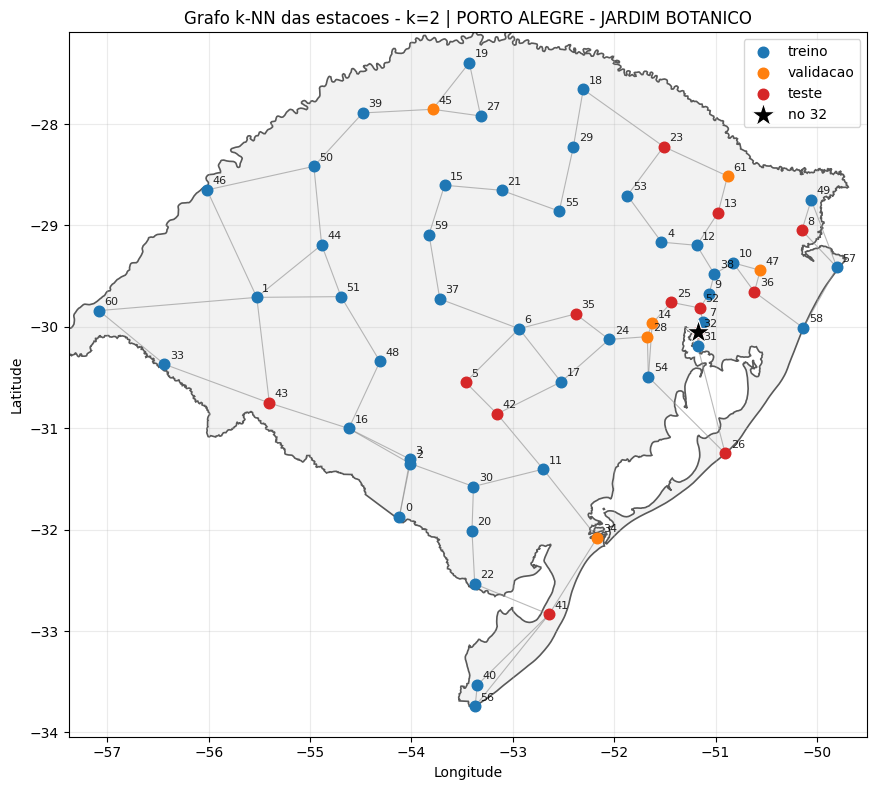

Vizinhos diretos do no 32 (PORTO ALEGRE - JARDIM BOTANICO) para k=2:
  no   7 -> CACHOEIRINHA
  no  31 -> PORTO ALEGRE - BELEM NOVO


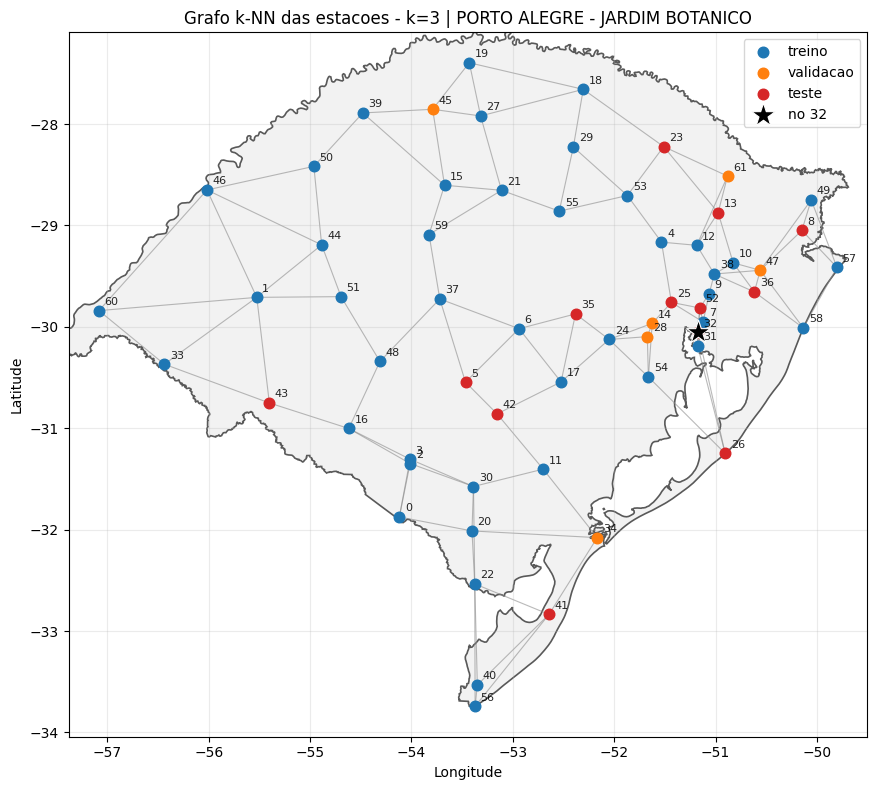

Vizinhos diretos do no 32 (PORTO ALEGRE - JARDIM BOTANICO) para k=3:
  no   7 -> CACHOEIRINHA
  no  26 -> MOSTARDAS
  no  31 -> PORTO ALEGRE - BELEM NOVO
  no  52 -> SAPUCAIA DO SUL


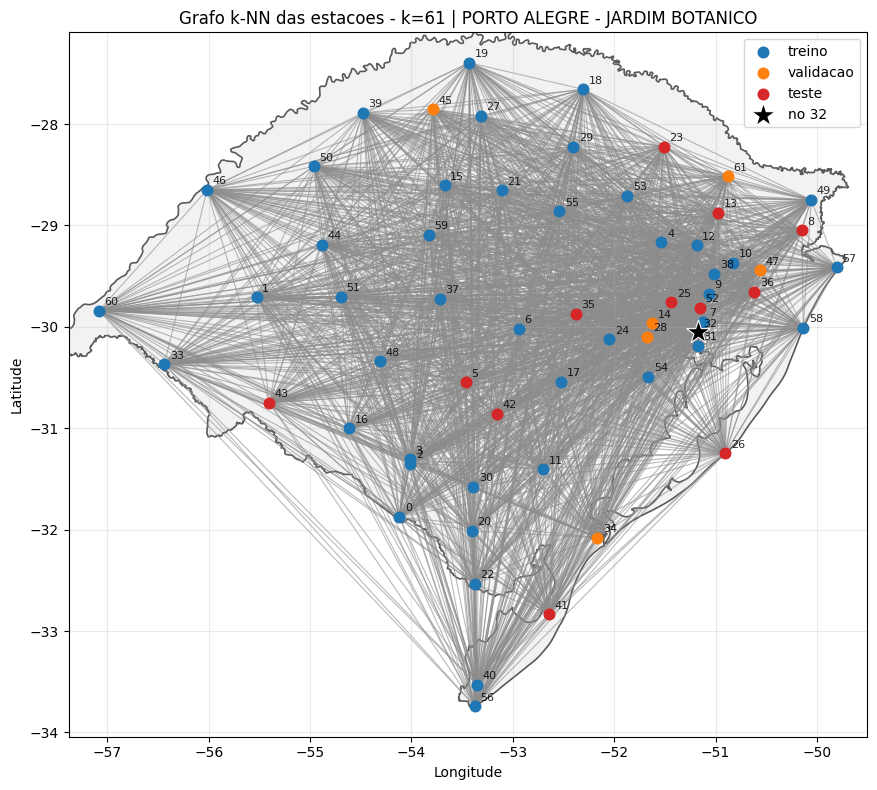

Vizinhos diretos do no 32 (PORTO ALEGRE - JARDIM BOTANICO) para k=61:
  no   0 -> ACEGUA
  no   1 -> ALEGRETE
  no   2 -> BAGE
  no   3 -> BAGE - CENTRO
  no   4 -> BENTO GONCALVES
  no   5 -> CACAPAVA DO SUL
  no   6 -> CACHOEIRA DO SUL
  no   7 -> CACHOEIRINHA
  no   8 -> CAMBARA DO SUL
  no   9 -> CAMPO BOM
  no  10 -> CANELA
  no  11 -> CANGUCU
  no  12 -> CAXIAS DO SUL - AEROPORTO
  no  13 -> CAXIAS DO SUL - CRIUVA
  no  14 -> CHARQUEADAS
  no  15 -> CRUZ ALTA
  no  16 -> DOM PEDRITO
  no  17 -> ENCRUZILHADA DO SUL
  no  18 -> ERECHIM
  no  19 -> FREDERICO WESTPHALEN
  no  20 -> HERVAL
  no  21 -> IBIRUBA
  no  22 -> JAGUARAO
  no  23 -> LAGOA VERMELHA
  no  24 -> MINAS DO LEAO
  no  25 -> MONTENEGRO
  no  26 -> MOSTARDAS
  no  27 -> PALMEIRA DAS MISSOES
  no  28 -> PARQUE ELDORADO
  no  29 -> PASSO FUNDO
  no  30 -> PINHEIRO MACHADO
  no  31 -> PORTO ALEGRE - BELEM NOVO
  no  33 -> QUARAI
  no  34 -> RIO GRANDE
  no  35 -> RIO PARDO
  no  36 -> ROLANTE
  no  37 -> SANTA MARIA
  n

In [34]:
import json
import gzip
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors


def carregar_mapa_rs_ibge():
    url = "https://servicodados.ibge.gov.br/api/v3/malhas/estados/43?formato=application/vnd.geo+json"

    req = urllib.request.Request(
        url,
        headers={
            "User-Agent": "Mozilla/5.0",
            "Accept": "application/json, application/geo+json",
            "Accept-Encoding": "identity",
        }
    )

    with urllib.request.urlopen(req) as resposta:
        dados = resposta.read()

    # Se vier compactado em gzip, descompacta antes de decodificar
    if dados[:2] == b"\x1f\x8b":
        dados = gzip.decompress(dados)

    return json.loads(dados.decode("utf-8"))


def plot_geojson(ax, geojson, facecolor="#f2f2f2", edgecolor="0.35", linewidth=1.2):
    for feature in geojson["features"]:
        geom = feature["geometry"]

        if geom["type"] == "Polygon":
            polygons = [geom["coordinates"]]
        elif geom["type"] == "MultiPolygon":
            polygons = geom["coordinates"]
        else:
            continue

        for polygon in polygons:
            exterior = polygon[0]
            lons = [p[0] for p in exterior]
            lats = [p[1] for p in exterior]

            ax.fill(
                lons,
                lats,
                facecolor=facecolor,
                edgecolor=edgecolor,
                linewidth=linewidth,
                zorder=0
            )


def build_adjacency(coords, k=2, include_self=False):
    coords = np.asarray(coords, dtype=float)
    N = coords.shape[0]

    if k >= N:
        raise ValueError(f"k={k} precisa ser menor que o numero de nos N={N}.")

    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(coords)
    _, idx = nbrs.kneighbors(coords)
    idx = idx[:, 1:]

    A_bin = np.zeros((N, N), dtype=bool)

    for i in range(N):
        A_bin[i, idx[i]] = True

    A_bin = A_bin | A_bin.T

    if include_self:
        np.fill_diagonal(A_bin, True)
    else:
        np.fill_diagonal(A_bin, False)

    return A_bin


def as_numpy_mask(mask):
    if hasattr(mask, "detach"):
        return mask.detach().cpu().numpy().astype(bool)
    return np.asarray(mask, dtype=bool)


def plot_knn_graph(coords, k=2, n_idx=32, nomes=None,
                   mask_train=None, mask_val=None, mask_test=None,
                   figsize=(11, 8), label_nodes=True,
                   mapa_rs=None):

    coords = np.asarray(coords, dtype=float)
    A_bin = build_adjacency(coords, k=k, include_self=False)
    N = coords.shape[0]

    fig, ax = plt.subplots(figsize=figsize)

    if mapa_rs is not None:
        plot_geojson(ax, mapa_rs)

    for i in range(N):
        for j in range(i + 1, N):
            if A_bin[i, j]:
                ax.plot(
                    [coords[i, 1], coords[j, 1]],
                    [coords[i, 0], coords[j, 0]],
                    color="0.55",
                    linewidth=0.8,
                    alpha=0.6,
                    zorder=1,
                )

    if mask_train is not None and mask_val is not None and mask_test is not None:
        train = as_numpy_mask(mask_train)
        val = as_numpy_mask(mask_val)
        test = as_numpy_mask(mask_test)

        ax.scatter(coords[train, 1], coords[train, 0], s=58, c="tab:blue", label="treino", zorder=3)
        ax.scatter(coords[val, 1], coords[val, 0], s=58, c="tab:orange", label="validacao", zorder=3)
        ax.scatter(coords[test, 1], coords[test, 0], s=58, c="tab:red", label="teste", zorder=3)
    else:
        ax.scatter(coords[:, 1], coords[:, 0], s=58, c="tab:blue", label="estacoes", zorder=3)

    ax.scatter(
        coords[n_idx, 1],
        coords[n_idx, 0],
        s=320,
        marker="*",
        c="black",
        edgecolors="white",
        linewidths=0.8,
        label=f"no {n_idx}",
        zorder=5,
    )

    if label_nodes:
        for i in range(N):
            ax.annotate(
                str(i),
                (coords[i, 1], coords[i, 0]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
                alpha=0.85,
                zorder=6,
            )

    vizinhos = np.where(A_bin[n_idx])[0]
    nome_no = nomes[n_idx] if nomes is not None else f"no {n_idx}"

    lon = coords[:, 1]
    lat = coords[:, 0]

    ax.set_xlim(lon.min() - 0.3, lon.max() + 0.3)
    ax.set_ylim(lat.min() - 0.3, lat.max() + 0.3)
    ax.set_aspect("equal", adjustable="box")

    ax.set_title(f"Grafo k-NN das estacoes - k={k} | {nome_no}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")

    plt.tight_layout()
    plt.show()

    print(f"Vizinhos diretos do no {n_idx} ({nome_no}) para k={k}:")
    for j in vizinhos:
        nome_vizinho = nomes[j] if nomes is not None else f"no {j}"
        print(f"  no {j:3d} -> {nome_vizinho}")

    return A_bin


mapa_rs = carregar_mapa_rs_ibge()

A_grafo2 = plot_knn_graph(coords, k=2, n_idx=n_idx, nomes=nomes,
                          mask_train=mask_train, mask_val=mask_val, mask_test=mask_test,
                          figsize=(11, 8), label_nodes=True, mapa_rs=mapa_rs)

A_grafo3 = plot_knn_graph(coords, k=3, n_idx=n_idx, nomes=nomes,
                          mask_train=mask_train, mask_val=mask_val, mask_test=mask_test,
                          figsize=(11, 8), label_nodes=True, mapa_rs=mapa_rs)

A_grafo61 = plot_knn_graph(coords, k=61, n_idx=n_idx, nomes=nomes,
                           mask_train=mask_train, mask_val=mask_val, mask_test=mask_test,
                           figsize=(11, 8), label_nodes=True, mapa_rs=mapa_rs)

## Extra: Plot para todos os k=1,...,61

In [35]:
# from pathlib import Path

# # =====================================================
# # Valores de k que voce quer testar/plotar
# # =====================================================

# k_grid = [2, 3, 61]

# # Pasta onde os graficos dos grafos serao salvos
# grafos_dir = Path("../Grafos")
# grafos_dir.mkdir(parents=True, exist_ok=True)

# target_date_file = target_date.replace("-", "")


# def plot_knn_graph(coords, k=2, n_idx=32, nomes=None,
#                    mask_train=None, mask_val=None, mask_test=None,
#                    figsize=(11, 8), label_nodes=True,
#                    mapa_rs=None, save_path=None):

#     coords = np.asarray(coords, dtype=float)
#     A_bin = build_adjacency(coords, k=k, include_self=False)
#     N = coords.shape[0]

#     fig, ax = plt.subplots(figsize=figsize)

#     if mapa_rs is not None:
#         plot_geojson(ax, mapa_rs)

#     for i in range(N):
#         for j in range(i + 1, N):
#             if A_bin[i, j]:
#                 ax.plot(
#                     [coords[i, 1], coords[j, 1]],
#                     [coords[i, 0], coords[j, 0]],
#                     color="0.55",
#                     linewidth=0.8,
#                     alpha=0.6,
#                     zorder=1,
#                 )

#     if mask_train is not None and mask_val is not None and mask_test is not None:
#         train = as_numpy_mask(mask_train)
#         val = as_numpy_mask(mask_val)
#         test = as_numpy_mask(mask_test)

#         ax.scatter(coords[train, 1], coords[train, 0], s=58, c="tab:blue", label="treino", zorder=3)
#         ax.scatter(coords[val, 1], coords[val, 0], s=58, c="tab:orange", label="validacao", zorder=3)
#         ax.scatter(coords[test, 1], coords[test, 0], s=58, c="tab:red", label="teste", zorder=3)
#     else:
#         ax.scatter(coords[:, 1], coords[:, 0], s=58, c="tab:blue", label="estacoes", zorder=3)

#     ax.scatter(
#         coords[n_idx, 1],
#         coords[n_idx, 0],
#         s=320,
#         marker="*",
#         c="black",
#         edgecolors="white",
#         linewidths=0.8,
#         label=f"no {n_idx}",
#         zorder=5,
#     )

#     if label_nodes:
#         for i in range(N):
#             ax.annotate(
#                 str(i),
#                 (coords[i, 1], coords[i, 0]),
#                 xytext=(4, 4),
#                 textcoords="offset points",
#                 fontsize=8,
#                 alpha=0.85,
#                 zorder=6,
#             )

#     vizinhos = np.where(A_bin[n_idx])[0]
#     nome_no = nomes[n_idx] if nomes is not None else f"no {n_idx}"

#     lon = coords[:, 1]
#     lat = coords[:, 0]

#     ax.set_xlim(lon.min() - 0.3, lon.max() + 0.3)
#     ax.set_ylim(lat.min() - 0.3, lat.max() + 0.3)
#     ax.set_aspect("equal", adjustable="box")

#     ax.set_title(f"Grafo k-NN das estacoes - k={k} | {nome_no}")
#     ax.set_xlabel("Longitude")
#     ax.set_ylabel("Latitude")
#     ax.grid(alpha=0.25)
#     ax.legend(loc="best")

#     plt.tight_layout()

#     if save_path is not None:
#         fig.savefig(save_path, dpi=300, bbox_inches="tight")
#         print(f"Grafico salvo em: {save_path}")

#     plt.show()

#     print(f"\nVizinhos diretos do no {n_idx} ({nome_no}) para k={k}:")
#     for j in vizinhos:
#         nome_vizinho = nomes[j] if nomes is not None else f"no {j}"
#         print(f"  no {j:3d} -> {nome_vizinho}")

#     return A_bin


# # =====================================================
# # Gera e salva todos os grafos para os valores de k
# # =====================================================

# mapa_rs = carregar_mapa_rs_ibge()

# grafos_por_k = {}

# for k_atual in k_grid:
#     nome_imagem = f"Grafo-K{k_atual}.png"
#     output_path = grafos_dir / nome_imagem

#     grafos_por_k[k_atual] = plot_knn_graph(
#         coords,
#         k=k_atual,
#         n_idx=n_idx,
#         nomes=nomes,
#         mask_train=mask_train,
#         mask_val=mask_val,
#         mask_test=mask_test,
#         figsize=(11, 8),
#         label_nodes=True,
#         mapa_rs=mapa_rs,
#         save_path=output_path,
#     )

In [ ]:
from pathlib import Path
import subprocess
import shutil
import pandas as pd

# =====================================================
# Configuração de caminhos
# =====================================================

root = Path("..") if Path.cwd().name == "Notebooks" else Path(".")

tables_dir = root / "Tables"
tables_loss_dir = root / "Tables_Loss"
results_dir = root / "Results"
graphics_dir = root / "Graphics"

tables_dir.mkdir(parents=True, exist_ok=True)
tables_loss_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)
graphics_dir.mkdir(parents=True, exist_ok=True)

main_tex_path = root / "Relatorio_Completo.tex"
main_pdf_path = root / "Relatorio_Completo.pdf"


# =====================================================
# Funções auxiliares
# =====================================================

def latex_path(path):
    return path.relative_to(root).as_posix()


def escape_caption(text):
    return (
        str(text)
        .replace("\\", r"\textbackslash{}")
        .replace("_", r"\_")
        .replace("%", r"\%")
        .replace("&", r"\&")
        .replace("#", r"\#")
    )


def input_tex_files(files):
    if not files:
        return "Nenhum arquivo encontrado."

    return "\n\n".join(
        f"\\input{{{latex_path(p)}}}"
        for p in files
    )


def graphics_to_latex(files):
    if not files:
        return "Nenhum gráfico encontrado."

    blocks = []

    for p in files:
        caption = escape_caption(p.stem)

        blocks.append(f"""
\\begin{{figure}}[H]
\\centering
\\includegraphics[width=0.95\\textwidth]{{{latex_path(p)}}}
\\caption{{{caption}}}
\\end{{figure}}
""")

    return "\n".join(blocks)


def csv_files_to_latex(files):
    if not files:
        return "Nenhum CSV encontrado."

    blocks = []

    for p in files:
        df_csv = pd.read_csv(p)

        caption = escape_caption(p.stem)
        label = (
            "tab:"
            + p.stem.lower()
            .replace("_", "-")
            .replace(" ", "-")
        )

        latex_csv = df_csv.to_latex(
            index=False,
            escape=True,
            float_format=lambda x: f"{x:.6f}",
            caption=caption,
            label=label,
            column_format="c" * len(df_csv.columns),
            position="H",
        )

        # Redimensiona apenas o tabular, deixando caption/label fora do resizebox
        latex_csv = latex_csv.replace(
            "\\begin{tabular}",
            "\\resizebox{\\textwidth}{!}{%\n\\begin{tabular}"
        )

        latex_csv = latex_csv.replace(
            "\\end{tabular}",
            "\\end{tabular}%\n}"
        )

        blocks.append(latex_csv)

    return "\n\n".join(blocks)


# =====================================================
# Coleta automática dos arquivos
# =====================================================

tables = sorted(tables_dir.glob("*.tex"))
tables_loss = sorted(tables_loss_dir.glob("*.tex"))
results = sorted(results_dir.glob("*.csv"))

graphics = sorted([
    *graphics_dir.glob("*.png"),
    *graphics_dir.glob("*.jpg"),
    *graphics_dir.glob("*.jpeg"),
    *graphics_dir.glob("*.pdf"),
])


# =====================================================
# Gera/atualiza o arquivo principal .tex
# =====================================================

main_tex = f"""
\\documentclass[12pt]{{article}}

\\usepackage[utf8]{{inputenc}}
\\usepackage[T1]{{fontenc}}
\\usepackage[brazil]{{babel}}
\\usepackage{{booktabs}}
\\usepackage{{geometry}}
\\usepackage{{float}}
\\usepackage{{graphicx}}
\\usepackage{{adjustbox}}
\\usepackage{{pdflscape}}

\\geometry{{a4paper, margin=2cm}}

\\begin{{document}}

\\title{{Relatório de Resultados GNN e GCN}}
\\author{{}}
\\date{{\\today}}
\\maketitle

\\section*{{Tabelas de Resultados}}

{input_tex_files(tables)}

\\clearpage

\\section*{{Tabelas de Loss por Nó}}

{input_tex_files(tables_loss)}

\\clearpage

\\section*{{Resultados CSV}}

{csv_files_to_latex(results)}

\\clearpage

\\section*{{Gráficos}}

{graphics_to_latex(graphics)}

\\end{{document}}
"""

main_tex_path.write_text(main_tex, encoding="utf-8")

print(f"Arquivo .tex atualizado em: {main_tex_path}")


# =====================================================
# Compila o PDF
# =====================================================

pdflatex_path = shutil.which("pdflatex")

if pdflatex_path is None:
    print("pdflatex não encontrado. Compile manualmente no VS Code ou no MiKTeX:")
    print(f"pdflatex {main_tex_path.name}")
else:
    for _ in range(2):
        subprocess.run(
            [
                pdflatex_path,
                "-interaction=nonstopmode",
                "-halt-on-error",
                main_tex_path.name,
            ],
            cwd=root,
            check=True,
        )

    print(f"PDF atualizado em: {main_pdf_path}")